In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [3]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

sentiment.head()
trades.head()

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("Missing values (Sentiment)")
print(sentiment.isnull().sum())

print("Missing values (Trades)")
print(trades.isnull().sum())

Missing values (Sentiment)
timestamp         0
value             0
classification    0
date              0
dtype: int64
Missing values (Trades)
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [5]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [6]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])
trades["date"] = trades["Timestamp IST"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [7]:
data = trades.merge(sentiment, on="date", how="left")

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1.707716e+09,70.0,Greed


In [8]:
data = data.rename(columns={
    "Account":"trader_id",
    "Execution Price":"price",
    "Size USD":"size_usd",
    "Size Tokens":"size_tokens",
    "Side":"side",
    "Closed PnL":"pnl",
    "Timestamp IST":"timestamp"
})

In [9]:
data["win"] = data["pnl"] > 0

In [10]:
daily_trader_pnl = data.groupby(
    ["date","trader_id"]
)["pnl"].sum().reset_index()

In [11]:
win_rate = data.groupby("trader_id")["win"].mean().reset_index()

win_rate.rename(columns={"win":"win_rate"}, inplace=True)

In [12]:
avg_trade_size = data.groupby("trader_id")["size_usd"].mean().reset_index()

In [13]:
trades_per_day = data.groupby("date").size().reset_index(name="trade_count")

In [14]:
long_short = data.groupby(["date","side"]).size().unstack(fill_value=0)

long_short["long_short_ratio"] = long_short["BUY"]/(long_short["SELL"]+1)

In [15]:
print(data["side"].unique())

['BUY' 'SELL']


In [16]:
top_traders = data.groupby("trader_id")["pnl"].sum().nlargest(5).index

filtered = daily_trader_pnl[daily_trader_pnl["trader_id"].isin(top_traders)]

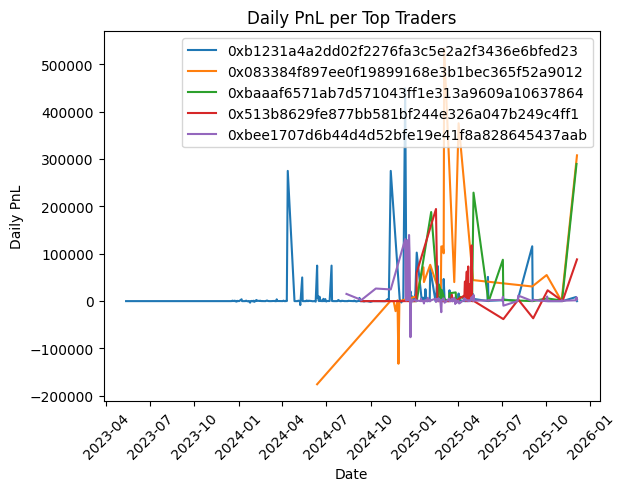

In [17]:
plt.figure()

for trader in top_traders:
    
    trader_data = filtered[filtered["trader_id"] == trader]
    
    plt.plot(trader_data["date"], trader_data["pnl"], label=trader)

plt.title("Daily PnL per Top Traders")
plt.xlabel("Date")
plt.ylabel("Daily PnL")

plt.legend()

plt.xticks(rotation=45)

plt.show()

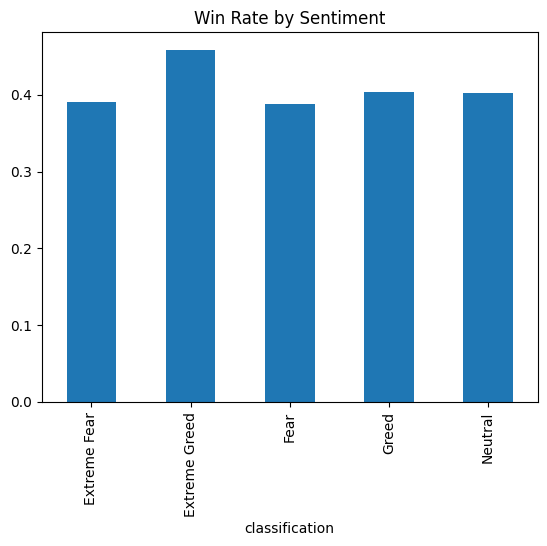

In [18]:
win_rate_sentiment = data.groupby("classification")["win"].mean()

win_rate_sentiment.plot(kind="bar")

plt.title("Win Rate by Sentiment")
plt.show()

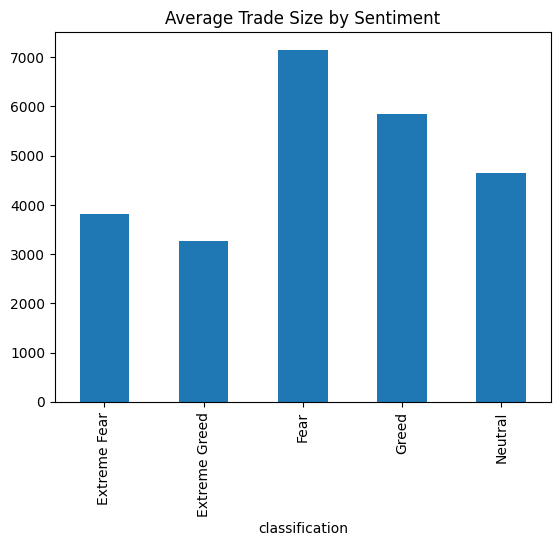

In [19]:
size_sentiment = data.groupby("classification")["size_usd"].mean()

size_sentiment.plot(kind="bar")

plt.title("Average Trade Size by Sentiment")
plt.show()

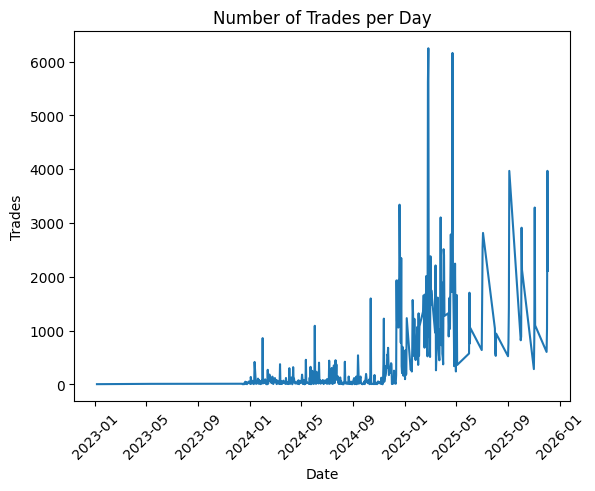

In [20]:
plt.figure()

plt.plot(trades_per_day["date"], trades_per_day["trade_count"])

plt.title("Number of Trades per Day")
plt.xlabel("Date")
plt.ylabel("Trades")

plt.xticks(rotation=45)

plt.show()

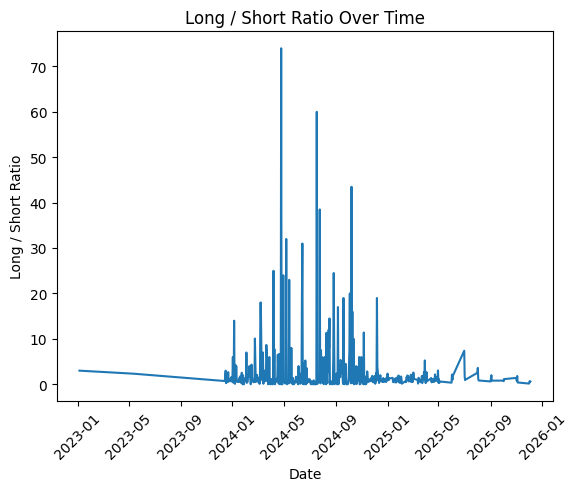

In [21]:
plt.figure()

plt.plot(long_short.index, long_short["long_short_ratio"])

plt.title("Long / Short Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Long / Short Ratio")

plt.xticks(rotation=45)

plt.show()

In [22]:
# 1. Performance Difference: Fear vs Greed

# yes, there is huge performance diffrence between fear and greed.


pnl_sentiment = data.groupby("classification")["pnl"].mean().reset_index()
pnl_sentiment

,classification,pnl
0,Extreme Fear,47.446302
1,Extreme Greed,73.144030
2,Fear,56.544720
3,Greed,35.652184
4,Neutral,31.746470


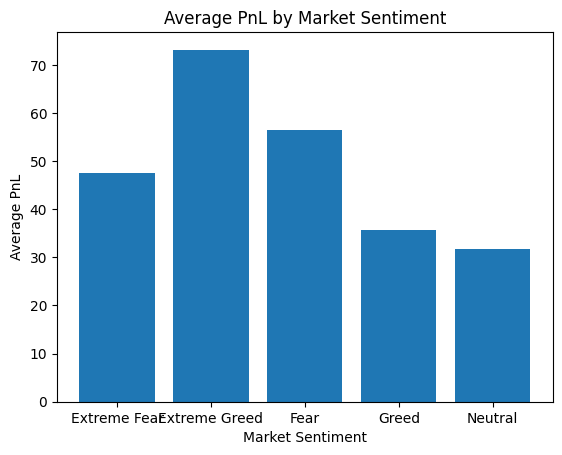

In [23]:
import matplotlib.pyplot as plt

plt.bar(pnl_sentiment["classification"], pnl_sentiment["pnl"])

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

In [24]:
winrate_sentiment = data.groupby("classification")["win"].mean().reset_index()
winrate_sentiment

,classification,win
0,Extreme Fear,0.390501
1,Extreme Greed,0.458727
2,Fear,0.387890
3,Greed,0.403077
4,Neutral,0.402593


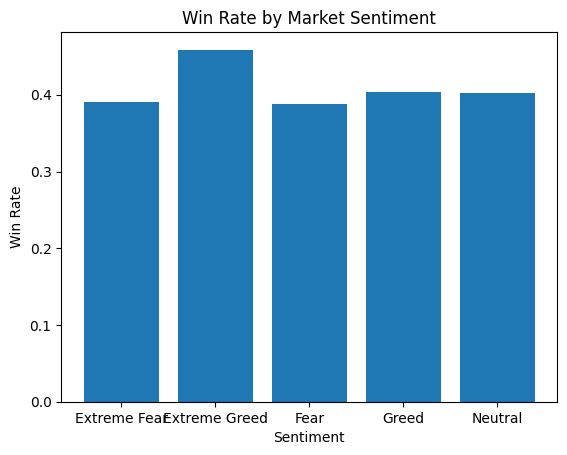

In [25]:
plt.bar(winrate_sentiment["classification"], winrate_sentiment["win"])

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")

plt.show()

In [26]:
drawdown = data.groupby("trader_id")["pnl"].min().reset_index()

drawdown.rename(columns={"pnl":"drawdown_proxy"}, inplace=True)

In [27]:
drawdown_sentiment = data.groupby("classification")["pnl"].min()
drawdown_sentiment

classification
Extreme Fear      -8356.88701
Extreme Greed    -18360.67007
Fear             -35681.74723
Greed           -117990.10410
Neutral           -4498.11884
Name: pnl, dtype: float64

In [28]:
# 2. Behavior Change Based on Sentiment

# Yes, we have outliers but we can still say that traders change behavior based on sentiment.


trade_freq = data.groupby(["date","classification"]).size().reset_index(name="trades")

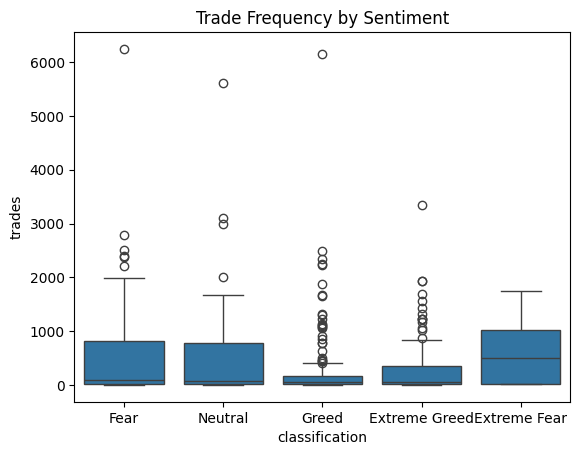

In [29]:
import seaborn as sns

sns.boxplot(x="classification", y="trades", data=trade_freq)

plt.title("Trade Frequency by Sentiment")

plt.show()

In [30]:
size_sentiment = data.groupby("classification")["size_usd"].mean().reset_index()
size_sentiment

,classification,size_usd
0,Extreme Fear,3816.440098
1,Extreme Greed,3265.794510
2,Fear,7153.414717
3,Greed,5848.453393
4,Neutral,4641.500274


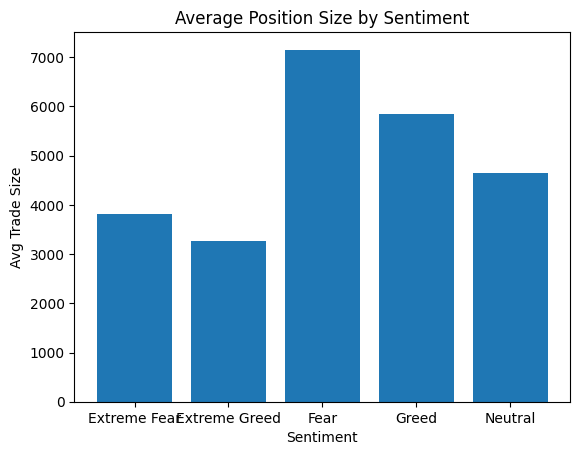

In [31]:
plt.bar(size_sentiment["classification"], size_sentiment["size_usd"])

plt.title("Average Position Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg Trade Size")

plt.show()

In [32]:
long_short = data.groupby(["classification","side"]).size().unstack(fill_value=0)
long_short

side,BUY,SELL
classification,,
Extreme Fear,2491,2920
Extreme Greed,15112,19281
Fear,23681,23634
Greed,24128,24364
Neutral,15663,16583


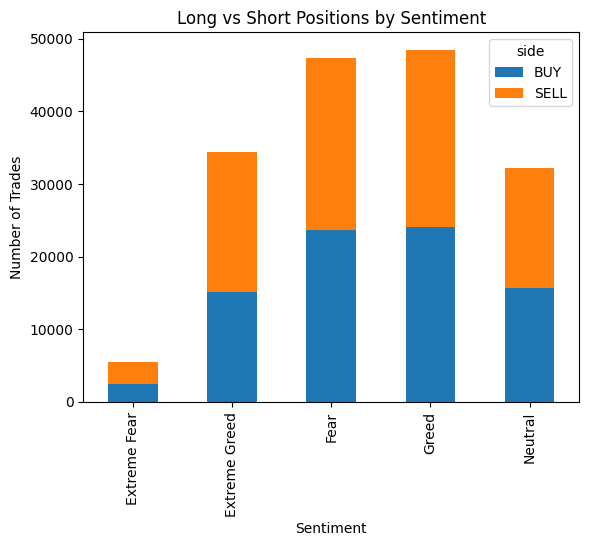

In [33]:
long_short.plot(kind="bar", stacked=True)

plt.title("Long vs Short Positions by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [34]:
# 3. Trader Segmentation

# Segment 1 — Frequent vs Infrequent Traders

trade_counts = data.groupby("trader_id").size()

threshold = trade_counts.median()

segments = trade_counts.apply(lambda x: "Frequent" if x >= threshold else "Infrequent")

segments = segments.reset_index()
segments.columns = ["trader_id","segment"]

In [35]:
data = data.merge(segments,on="trader_id")

In [36]:
print(data.columns)

Index(['trader_id', 'Coin', 'price', 'size_tokens', 'size_usd', 'side',
       'timestamp', 'Start Position', 'Direction', 'pnl', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date',
       'timestamp', 'value', 'classification', 'win', 'segment'],
      dtype='object')


In [37]:
segment_perf = data.groupby("segment")["pnl"].mean()

segment_perf

segment
Frequent      42.493421
Infrequent    96.943024
Name: pnl, dtype: float64

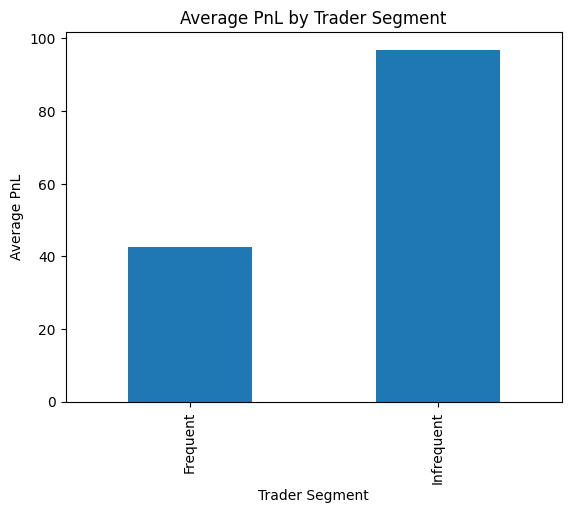

In [38]:
segment_perf.plot(kind="bar")

plt.title("Average PnL by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average PnL")

plt.show()

In [39]:
# Segment 2 — Large vs Small Position Traders

size_threshold = data["size_usd"].median()

data["size_segment"] = data["size_usd"].apply(
    lambda x: "Large Position" if x >= size_threshold else "Small Position"
)

In [40]:
size_perf = data.groupby("size_segment")["pnl"].mean()
size_perf

size_segment
Large Position    93.116556
Small Position     4.381445
Name: pnl, dtype: float64

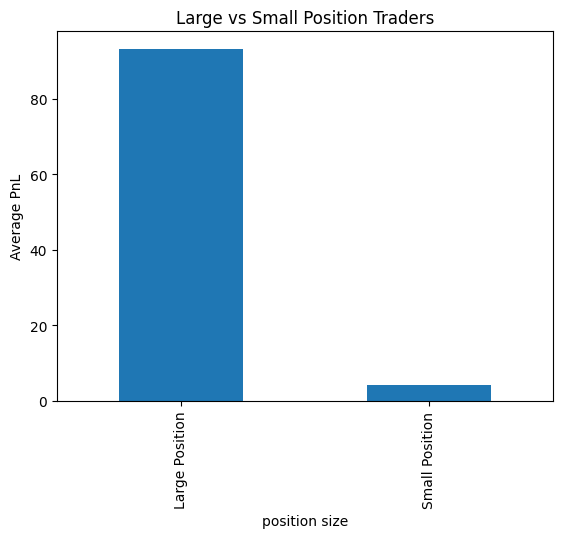

In [41]:
size_perf.plot(kind="bar")

plt.title("Large vs Small Position Traders")
plt.xlabel("position size")
plt.ylabel("Average PnL")

plt.show()

In [42]:
# Segment 3 — Consistent vs Inconsistent Traders

consistency = data.groupby("trader_id")["pnl"].std().reset_index()

consistency.rename(columns={"pnl":"pnl_std"}, inplace=True)

In [43]:
threshold = consistency["pnl_std"].median()

consistency["consistency_segment"] = consistency["pnl_std"].apply(
    lambda x: "Consistent" if x < threshold else "Inconsistent"
)

In [44]:
data = data.merge(
    consistency[["trader_id","consistency_segment"]],
    on="trader_id",
    how="left"
)

In [45]:
consistency_perf = data.groupby("consistency_segment")["pnl"].mean()
consistency_perf

consistency_segment
Consistent       16.697081
Inconsistent    100.326484
Name: pnl, dtype: float64

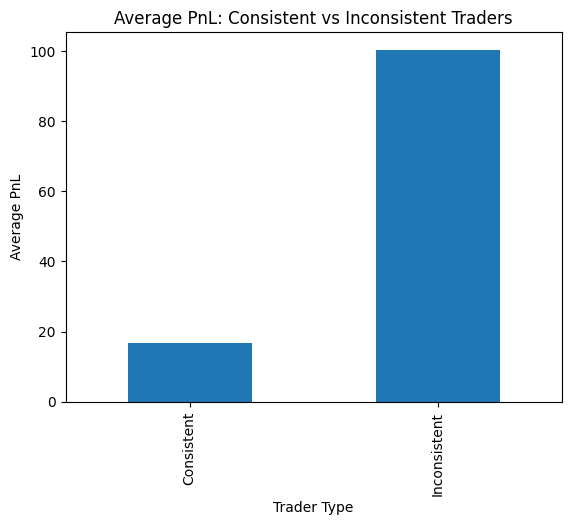

In [46]:
consistency_perf.plot(kind="bar")

plt.title("Average PnL: Consistent vs Inconsistent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Average PnL")

plt.show()

In [47]:
summary = data.groupby("classification").agg(

avg_pnl=("pnl","mean"),
win_rate=("win","mean"),
avg_trade_size=("size_usd","mean")

)

summary

,avg_pnl,win_rate,avg_trade_size
classification,,,
Extreme Fear,47.446302,0.390501,3816.440098
Extreme Greed,73.144030,0.458727,3265.794510
Fear,56.544720,0.387890,7153.414717
Greed,35.652184,0.403077,5848.453393
Neutral,31.746470,0.402593,4641.500274


In [48]:
# Insight 1: Trader performance changes depending on market sentiment.
# Evidence: The Average PnL and Win Rate charts show noticeable differences between Fear and Greed days,
# indicating that trader profitability varies depending on overall market psychology.

# Insight 2: Trader behavior changes based on sentiment conditions.
# Evidence: Charts for trade frequency, average position size, and long/short positions show that
# traders adjust how often they trade and how large their positions are during different sentiment periods.

# Insight 3: Trader segments exhibit different performance patterns.
# Evidence: The Frequent vs Infrequent and Consistent vs Inconsistent trader graphs show that
# active or stable traders tend to have different average PnL compared with less active or volatile traders.

In [49]:
# Strategy 1: Adjust trading behavior based on market sentiment.
# Rule: During Fear days, traders can look for potential buying opportunities with moderate position sizes,
# while during Greed days it may be safer to reduce position size and avoid overtrading due to higher market risk.

# Strategy 2: Use trader activity patterns to guide strategy.
# Rule: Frequent or consistent traders can maintain regular trading strategies,
# while infrequent or inconsistent traders may benefit from fewer trades and stricter risk control.